In [13]:
import pandas as pd

df = pd.read_excel(
    "/content/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

In [14]:
df.shape

(541910, 8)

In [15]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [16]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [18]:
df = df.dropna(subset=['Customer ID'])

In [19]:
df.shape

(406830, 8)

In [21]:
df = df.drop_duplicates()

In [22]:
df = df[df['Quantity'] > 0]

In [23]:
df = df[df['Price'] > 0]

In [24]:
df.shape

(392693, 8)

In [25]:
df['TotalAmount'] = (
    df['Quantity'] *
    df['Price']
)

In [26]:
df[['Quantity','Price','TotalAmount']].head()

,Quantity,Price,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [27]:
df['Year'] = df['InvoiceDate'].dt.year

df['Month'] = df['InvoiceDate'].dt.month

df['Quarter'] = df['InvoiceDate'].dt.quarter

df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [28]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalAmount', 'Year', 'Month',
       'Quarter', 'Weekday'],
      dtype='object')

In [33]:
monthly_sales = (
    df.groupby('Month')['TotalAmount']
      .sum()
)
print(monthly_sales)

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087631.170
Name: TotalAmount, dtype: float64


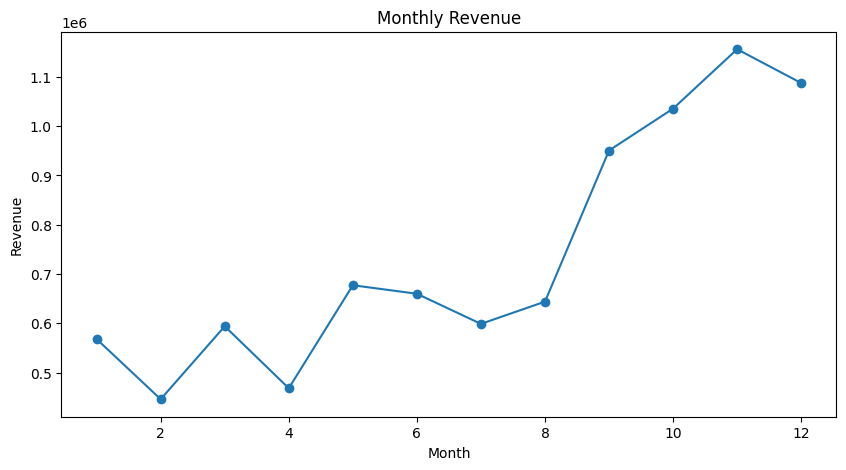

In [34]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77821.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64


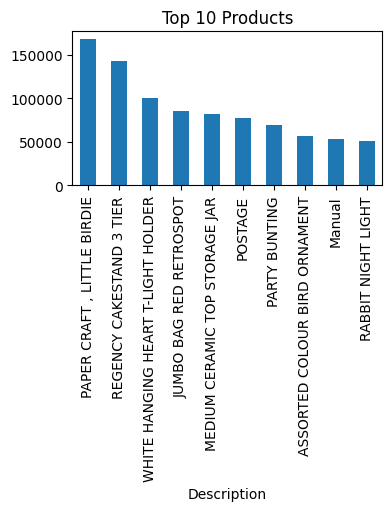

In [37]:
top_products = (
    df.groupby('Description')
      ['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(top_products)
top_products.plot(
    kind='bar',
    figsize=(4,2)
)

plt.title("Top 10 Products")
plt.show()

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208952.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

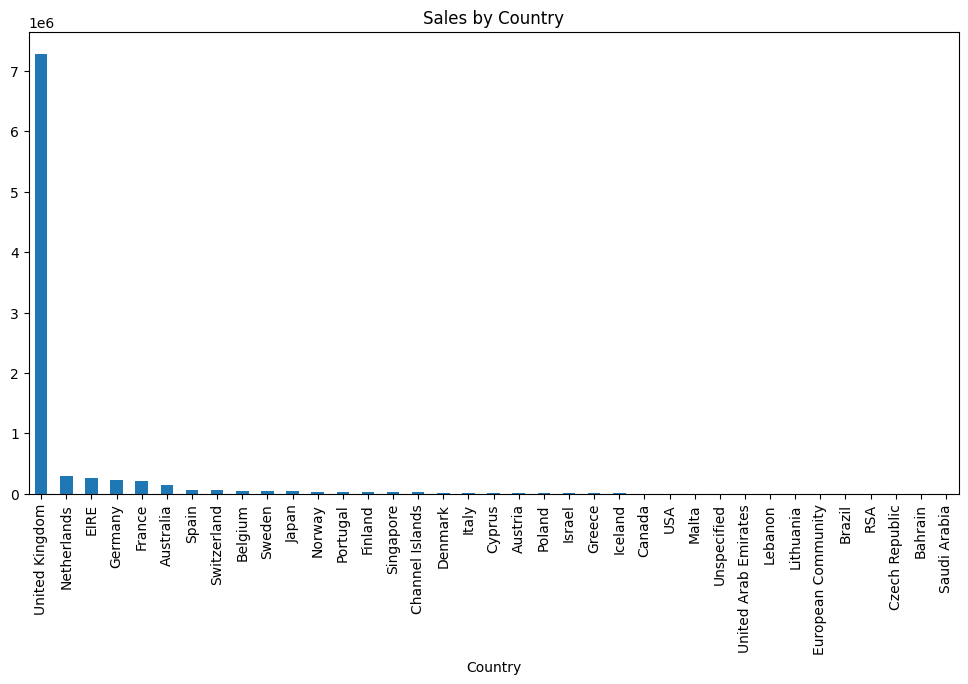

In [38]:
country_sales = (
    df.groupby('Country')
      ['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)
print(country_sales)
country_sales.plot(
    kind='bar',
    figsize=(12,6)
    )
plt.title("Sales by Country")
plt.show()

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
             ...    
16878.0        13.30
17956.0        12.75
16454.0         6.90
14792.0         6.20
16738.0         3.75
Name: TotalAmount, Length: 4338, dtype: float64


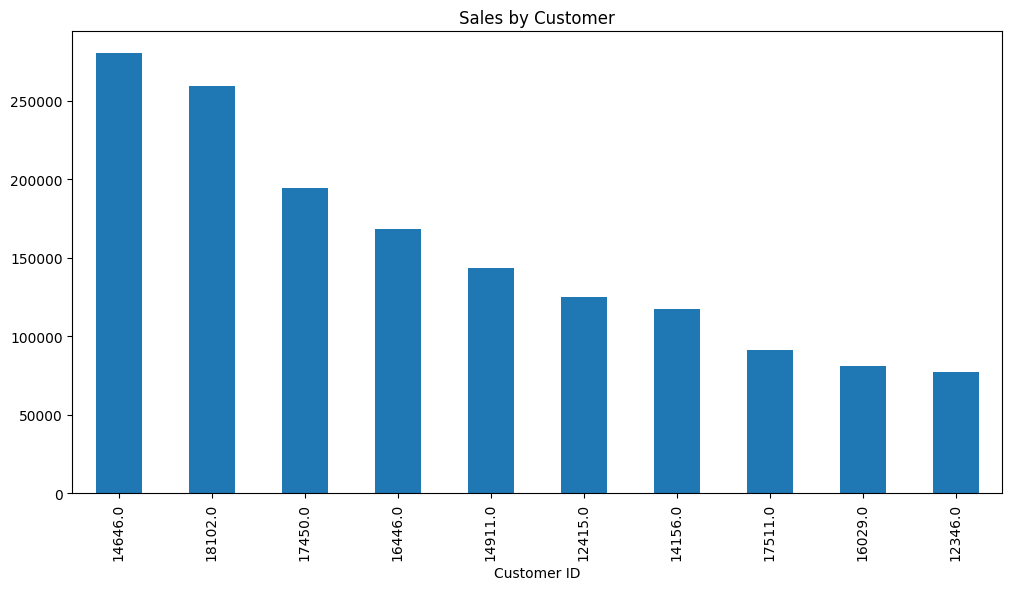

In [39]:
customer_sales = (
    df.groupby('Customer ID')
      ['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)
print(customer_sales)
customer_sales.head(10).plot(
    kind='bar',
    figsize=(12,6)
)
plt.title("Sales by Customer")
plt.show()

In [40]:
top_customers = (
    df.groupby('Customer ID')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalAmount, dtype: float64


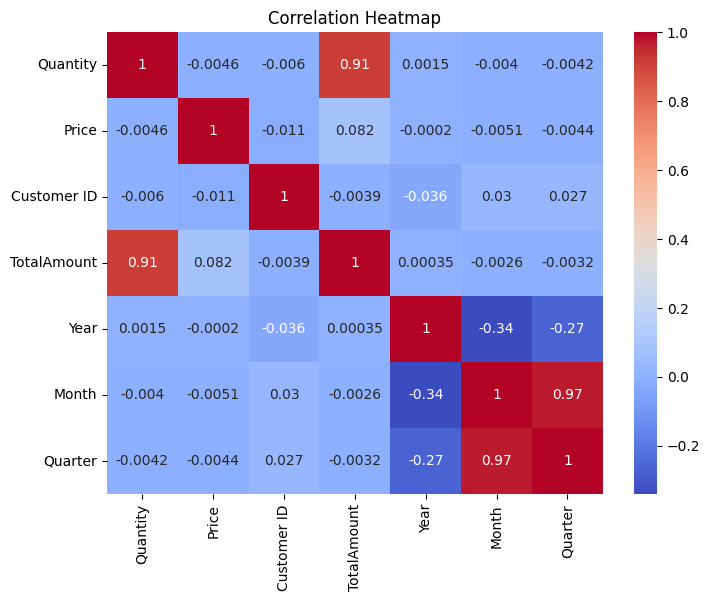

In [41]:
import seaborn as sns

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [44]:
plt.savefig(
    "monthly_sales_chart.png",
    bbox_inches='tight'
)
plt.show()

plt.savefig(
    "top_products_chart.png",
    bbox_inches='tight'
)
plt.show()

plt.savefig(
    "country_sales_chart.png",
    bbox_inches='tight'
)
plt.show()

plt.savefig(
    "top_customers_chart.png",
    bbox_inches='tight'
)
plt.show()

plt.savefig(
    "correlation_heatmap.png",
    bbox_inches='tight'
)
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [45]:
monthly_sales = (
    df.groupby('Month')['TotalAmount']
      .sum()
)

print(monthly_sales)

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087631.170
Name: TotalAmount, dtype: float64


In [47]:
print(df.shape)

print(monthly_sales.head())

print(top_products.head())

print(country_sales.head())

(392693, 13)
Month
1    568101.310
2    446084.920
3    594081.760
4    468374.331
5    677355.150
Name: TotalAmount, dtype: float64
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: TotalAmount, dtype: float64
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208952.310
Name: TotalAmount, dtype: float64
